# #Classification using Artificial Neural Networks

#Multi-Class Classification


In this example we will use a darts dataset that consist of dart throws by different competitors. The coordinate pairs xCoord and yCoord show where each dart landed. Each dart can only be thrown by one competitor. That means our classes are mutually exclusive, no dart can be thrown by two different competitors simultaneously.

Based on the landing position of previously thrown darts we should be able to distinguish between throwers if there's enough variation among them. In our pairplot we can see players tend to aim at certain regions of the board.

The model for this dataset has two neurons as inputs,since our predictors are xCoord and yCoord. We will define them using the input_shape argument



In [15]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import tensorflow as tf
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4f}'.format)

sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

imports ok


##Load Data

In [16]:
# Load data file
data = pd.read_csv("data/bcn_noise_class_ml_enriched.csv")

In [17]:
print(data["noise_day"].unique())

[2 1 3 4 0]


**DEFINE X AND Y AND SCALE**

In [18]:
#same code as last time

#declare features
X = data.drop(columns=['road_id','noise_day','noise_evening', 'noise_night','height','pois','transport','green_100','width']) 

#declare targets "classes"
y = data.noise_day

print(X)

       road_category  dist_to_trunk  dist_to_primary  dist_to_secondary  \
0                  4      1462.9321        2131.0929           492.9049   
1                  6      1420.2279        2300.0482           675.7213   
2                  5       232.6879         502.1247          1111.3417   
3                  3       588.4650        1609.3861             0.0000   
4                  4      1432.0293        1409.1215           149.2421   
...              ...            ...              ...                ...   
11706              5      1071.1698        2765.1042          1043.4939   
11707              5      1071.1698        2765.1042          1043.4939   
11708              5      1094.5658        2783.4601          1065.0462   
11709              5      1091.8133        2832.8509          1092.7353   
11710              5      1091.3269        2832.8509          1092.7353   

       dist_to_tertiary  dist_to_residential  dist_to_living_street  signals  \
0                0.

In [19]:
# Load and instantiate a StandardSclaer
from sklearn.preprocessing import StandardScaler
scalerX = StandardScaler()

# Apply the scaler to our X-features
X_scaled = scalerX.fit_transform(X)

print(X_scaled.shape)

(11711, 15)


**SPLIT**

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 21)

In [21]:
#visualize our data
#we can see that scikitlearn doesnt care if it is a dataframe or a numpy array, because they all function on the same way
print(X_train.shape)
print(y_test.shape)

(9368, 15)
(2343,)


# Build model

From the cheatSheet
Multiclass classification >>
      activation = relu for hidden layers / softmax for final layer
      loss = categorical cross entropy
      optimizer = adam
      input from data, is 2 columns
      output is 1 out of 4 classes

In [22]:
# If labels are 1..5, shift them to 0..4
y = data["noise_day"] - 1

n_features = X.shape[1]
n_classes = y.nunique()

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325 (1.27 KB)

 Trainable params: 325 (1.27 KB)

 Non-trainable params: 0 (0.00 B)

#Train model

In [24]:
# Fit your model to the training data for 200 epochs
#we assign this to history variable so we can plot the training data
history = model.fit(X_train,y_train,epochs=200, validation_split=0.1)

Epoch 1/200


264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5704 - loss: 0.9688 - val_accuracy: 0.5912 - val_loss: 0.8694
Epoch 2/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step - accuracy: 0.6067 - loss: 0.8601 - val_accuracy: 0.5955 - val_loss: 0.8538
Epoch 3/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - accuracy: 0.6099 - loss: 0.8435 - val_accuracy: 0.6062 - val_loss: 0.8589
Epoch 4/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step - accuracy: 0.6180 - loss: 0.8292 - val_accuracy: 0.6115 - val_loss: 0.8418
Epoch 5/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - accuracy: 0.6228 - loss: 0.8210 - val_accuracy: 0.6083 - val_loss: 0.8468
Epoch 6/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step - accuracy: 0.6218 - loss: 0.8180 - val_accuracy: 0.6158 - val_loss: 0.8303
Epoch 7/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 921us/step - accuracy: 0.6247 - loss: 0.8091 - val_accuracy: 0.6211 - val_loss: 0.8357
Epoch 8/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step - accuracy: 0.6297 - loss: 0.8068 - val_ac

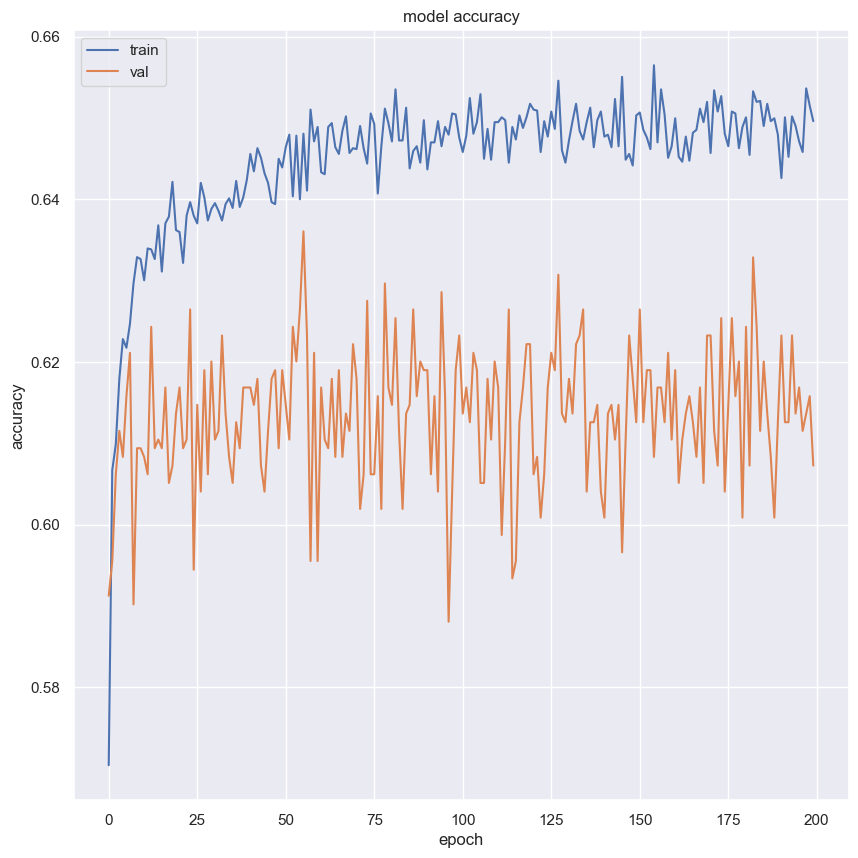

In [25]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

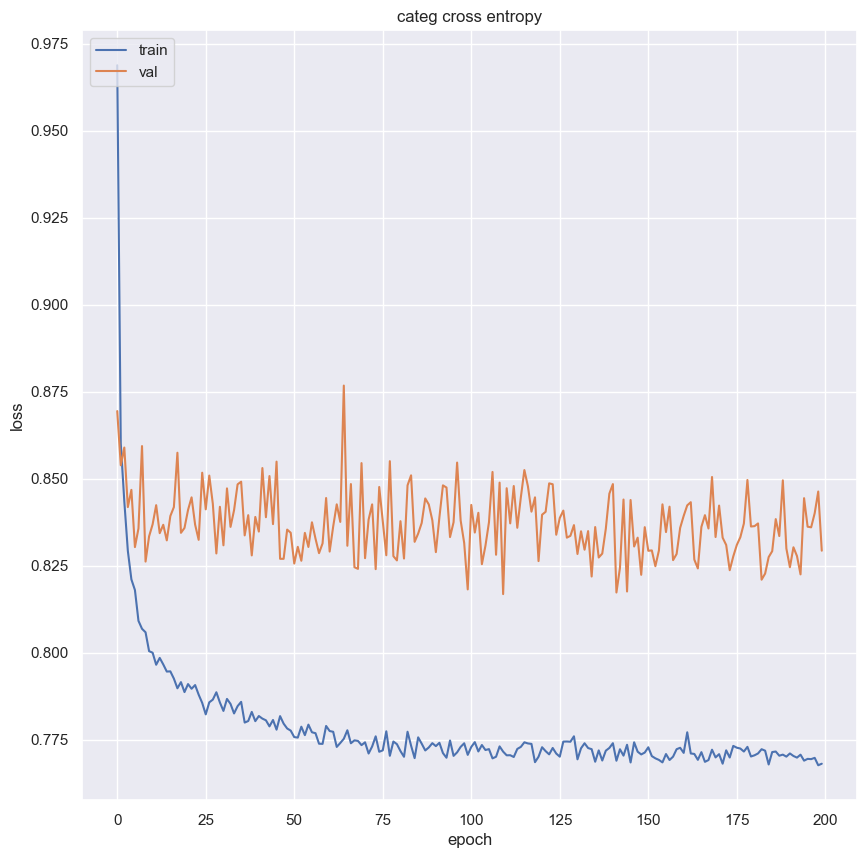

In [26]:
# summarize history for accuracy
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('categ cross entropy')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

#Evaluate model on test data

In [27]:
# Evaluate your model accuracy on the test data
accuracy = model.evaluate(X_test,y_test)[1]

# Print accuracy
print('Accuracy:', accuracy)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step - accuracy: 0.6240 - loss: 0.8128
Accuracy: 0.6239863634109497


##Plot results

To draw a confusion matrix, we would need to go back from onehot encoding to class, we do that with .argmax method which finds which column has the highest score

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step


(<Figure size 1000x1000 with 2 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

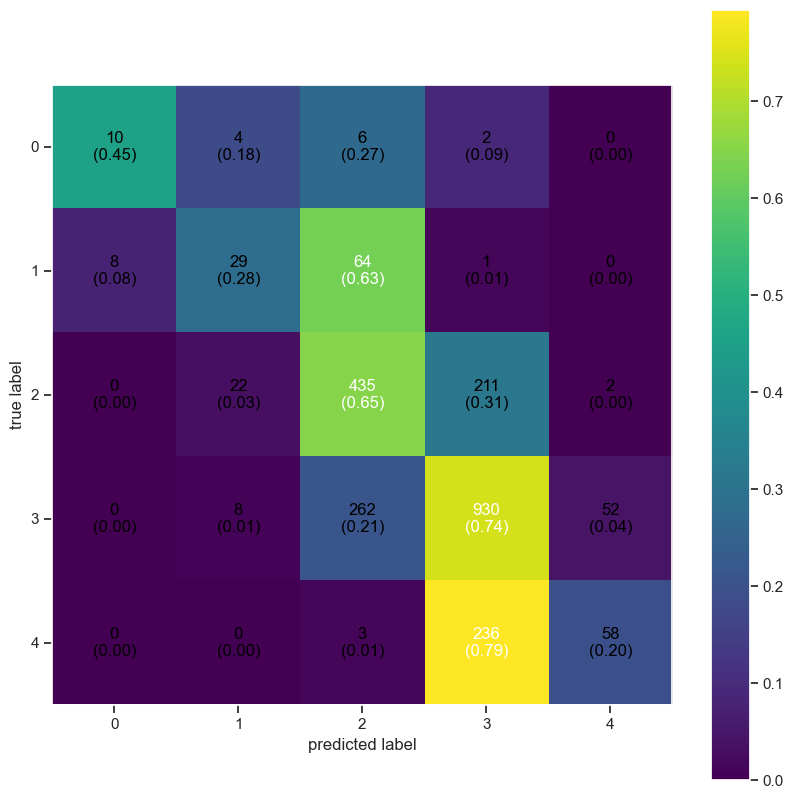

In [29]:
from sklearn.metrics import confusion_matrix
from mlxtend.plotting import plot_confusion_matrix

# Get class probabilities and convert them to class ids
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

# y_test is already a 1D vector of class ids
confmatrix = confusion_matrix(y_test, y_pred_classes)

plot_confusion_matrix(conf_mat=confmatrix,
                                colorbar=True,
                                show_absolute=True,
                                show_normed=True,
                                cmap='viridis')